# E-commerce Business Analytics

## Objective
Analyze the synthetic e-commerce dataset with Python and produce recruiter-friendly evidence for revenue, customers, products, returns, and profitability.

**Business definitions:** delivered orders are used for realized sales; Net Revenue = Net Sales before Returns − Refunds; Contribution Profit = Net Revenue − COGS − Shipping Cost.

## 1. Setup and imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Works when the notebook is opened from the project root or notebooks/ directory.
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"
OUT = ROOT / "notebooks" / "outputs"
OUT.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Data folder exists:", DATA.exists())

Project root: /home/rishabh/Projects/ecommerce_sql_project
Data folder exists: True


## 2. Load the CSV data

In [2]:
customers = pd.read_csv(DATA / "customers.csv", parse_dates=["signup_date"])
products = pd.read_csv(DATA / "products.csv")
campaigns = pd.read_csv(DATA / "campaigns.csv", parse_dates=["start_date", "end_date"])
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA / "order_items.csv")
returns = pd.read_csv(DATA / "returns.csv", parse_dates=["return_date"])

for name, df in {
    "customers": customers, "products": products, "campaigns": campaigns,
    "orders": orders, "order_items": order_items, "returns": returns
}.items():
    print(f"{name:15} {df.shape[0]:>8,} rows x {df.shape[1]} columns")

customers         20,000 rows x 9 columns
products             500 rows x 7 columns
campaigns              8 rows x 6 columns
orders            80,000 rows x 7 columns
order_items      163,710 rows x 6 columns
returns            6,479 rows x 7 columns


## 3. Data quality checks

In [3]:
quality = pd.Series({
    "customers_rows": len(customers),
    "products_rows": len(products),
    "campaigns_rows": len(campaigns),
    "orders_rows": len(orders),
    "order_items_rows": len(order_items),
    "returns_rows": len(returns),
    "duplicate_customer_ids": customers["customer_id"].duplicated().sum(),
    "duplicate_order_ids": orders["order_id"].duplicated().sum(),
    "duplicate_order_item_ids": order_items["order_item_id"].duplicated().sum(),
    "missing_customer_city": customers["city"].isna().sum(),
    "missing_acquisition_channel": customers["acquisition_channel"].isna().sum(),
    "invalid_order_customer_refs": (~orders["customer_id"].isin(customers["customer_id"])).sum(),
    "invalid_item_order_refs": (~order_items["order_id"].isin(orders["order_id"])).sum(),
    "invalid_item_product_refs": (~order_items["product_id"].isin(products["product_id"])).sum(),
    "invalid_return_item_refs": (~returns["order_item_id"].isin(order_items["order_item_id"])).sum(),
}, name="value")
quality.to_frame()

,value
customers_rows,20000
products_rows,500
campaigns_rows,8
orders_rows,80000
order_items_rows,163710
returns_rows,6479
duplicate_customer_ids,0
duplicate_order_ids,0
duplicate_order_item_ids,0
missing_customer_city,376


### Interpretation
The quality output should be reconciled with `sql/03_quality_checks.sql`. The project currently has 20,000 customers, 80,000 orders, 163,710 order items, 500 products, 8 campaigns and 6,479 returns. Missing city/acquisition-channel values are retained because they do not prevent revenue analysis.

## 4. Build a delivered line-level dataset

In [4]:
delivered_orders = orders.loc[orders["status"].eq("Delivered")].copy()

line = (
    order_items
    .merge(delivered_orders[["order_id", "customer_id", "order_date", "shipping_cost", "campaign_id"]],
           on="order_id", how="inner")
    .merge(products[["product_id", "product_name", "category", "subcategory", "brand", "unit_cost"]],
           on="product_id", how="left")
)

line["gross_sales"] = line["quantity"] * line["unit_price"]
line["discount_amount"] = line["gross_sales"] * line["discount_pct"]
line["net_sales"] = line["gross_sales"] - line["discount_amount"]
line["cogs"] = line["quantity"] * line["unit_cost"]

refunds_by_item = returns.groupby("order_item_id", as_index=False)["refund_amount"].sum()
refunds_by_item = refunds_by_item.rename(columns={"refund_amount": "refunds"})
line = line.merge(refunds_by_item, on="order_item_id", how="left")
line["refunds"] = line["refunds"].fillna(0)

line.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,customer_id,order_date,shipping_cost,campaign_id,product_name,category,subcategory,brand,unit_cost,gross_sales,discount_amount,net_sales,cogs,refunds
0,1,1,193,1,"23,309.52",0.10,16614,2025-05-19,94.44,1.00,Nexa Phones Product 0193,Electronics,Phones,Nexa,"15,233.67","23,309.52","2,330.95","20,978.57","15,233.67",0.00
1,2,1,11,1,"16,678.22",0.15,16614,2025-05-19,94.44,1.00,Prime Outdoor Product 0011,Sports,Outdoor,Prime,"6,375.76","16,678.22","2,501.73","14,176.49","6,375.76",0.00
2,3,1,197,1,"13,191.41",0.15,16614,2025-05-19,94.44,1.00,Prime Women Product 0197,Fashion,Women,Prime,"7,789.80","13,191.41","1,978.71","11,212.70","7,789.80",0.00
3,4,2,112,2,"28,370.31",0.00,6948,2025-02-12,148.03,NaN,Aster Kitchen Product 0112,Home,Kitchen,Aster,"17,640.78","56,740.62",0.00,"56,740.62","35,281.56","56,740.62"
4,5,3,114,1,"26,775.06",0.10,14046,2025-04-17,125.97,NaN,Zenith Storage Product 0114,Home,Storage,Zenith,"14,740.64","26,775.06","2,677.51","24,097.55","14,740.64",0.00


### Grain reminder
`orders` is one row per order. `order_items` is one row per order item. After joining them, `line` is at order-item grain. Therefore, order-level metrics such as AOV must be calculated after aggregating to one row per order.

In [5]:
order_level = (
    line.groupby(["order_id", "customer_id", "order_date", "shipping_cost"], as_index=False)
    .agg(net_sales=("net_sales", "sum"), refunds=("refunds", "sum"), cogs=("cogs", "sum"))
)
order_level["net_revenue"] = order_level["net_sales"] - order_level["refunds"]
order_level["contribution_profit"] = (
    order_level["net_revenue"] - order_level["cogs"] - order_level["shipping_cost"]
)
order_level.head()

,order_id,customer_id,order_date,shipping_cost,net_sales,refunds,cogs,net_revenue,contribution_profit
0,1,16614,2025-05-19,94.44,"46,367.75",0.00,"29,399.23","46,367.75","16,874.08"
1,2,6948,2025-02-12,148.03,"56,740.62","56,740.62","35,281.56",0.00,"-35,429.59"
2,3,14046,2025-04-17,125.97,"39,192.88","11,297.83","23,624.17","27,895.05","4,144.91"
3,4,1033,2025-06-15,57.74,"18,395.60",0.00,"7,789.66","18,395.60","10,548.20"
4,5,9365,2025-02-20,217.15,"180,820.24",0.00,"79,710.54","180,820.24","100,892.55"


## 5. KPI summary

In [6]:
kpis = pd.Series({
    "Delivered orders": order_level["order_id"].nunique(),
    "Purchasing customers": order_level["customer_id"].nunique(),
    "Gross sales": line["gross_sales"].sum(),
    "Discounts": line["discount_amount"].sum(),
    "Refunds": line["refunds"].sum(),
    "Net revenue": order_level["net_revenue"].sum(),
    "AOV": order_level["net_revenue"].mean(),
    "COGS": order_level["cogs"].sum(),
    "Shipping cost": order_level["shipping_cost"].sum(),
    "Contribution profit": order_level["contribution_profit"].sum(),
    "Contribution margin %": 100 * order_level["contribution_profit"].sum() / order_level["net_revenue"].sum(),
}, name="value")
kpis.to_frame()

,value
Delivered orders,"70,437.00"
Purchasing customers,"16,595.00"
Gross sales,"4,047,389,652.39"
Discounts,"337,195,367.89"
Refunds,"142,640,262.36"
Net revenue,"3,567,554,022.14"
AOV,"50,648.86"
COGS,"2,031,290,288.44"
Shipping cost,"9,152,894.38"
Contribution profit,"1,527,110,839.32"


In [7]:
kpis.to_frame("value").to_csv(OUT / "kpi_summary.csv")
print("Saved:", OUT / "kpi_summary.csv")

Saved: /home/rishabh/Projects/ecommerce_sql_project/notebooks/outputs/kpi_summary.csv


## 6. Monthly revenue and growth

In [8]:
monthly = (
    order_level.assign(month=order_level["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        contribution_profit=("contribution_profit", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique"),
    )
)
monthly["aov"] = monthly["revenue"] / monthly["orders"]
monthly["mom_growth_pct"] = monthly["revenue"].pct_change() * 100
monthly

,month,revenue,contribution_profit,orders,customers,aov,mom_growth_pct
0,2025-01-01,"300,693,127.56","129,542,941.29",5841,4529,"51,479.73",NaN
1,2025-02-01,"247,183,821.04","105,460,388.23",4835,3902,"51,123.85",-17.80
2,2025-03-01,"270,875,286.57","115,172,600.09",5361,4263,"50,527.01",9.58
3,2025-04-01,"258,665,327.37","110,111,002.08",5161,4057,"50,119.23",-4.51
4,2025-05-01,"297,030,669.54","127,536,441.47",5937,4585,"50,030.43",14.83
5,2025-06-01,"259,262,380.08","110,887,718.59",5176,4128,"50,089.33",-12.72
6,2025-07-01,"296,273,882.69","127,609,709.38",5883,4498,"50,361.02",14.28
7,2025-08-01,"270,587,912.88","116,349,723.36",5382,4233,"50,276.46",-8.67
8,2025-09-01,"266,580,393.52","114,157,742.14",5192,4092,"51,344.45",-1.48
9,2025-10-01,"369,526,538.78","158,197,411.21",7326,5326,"50,440.42",38.62


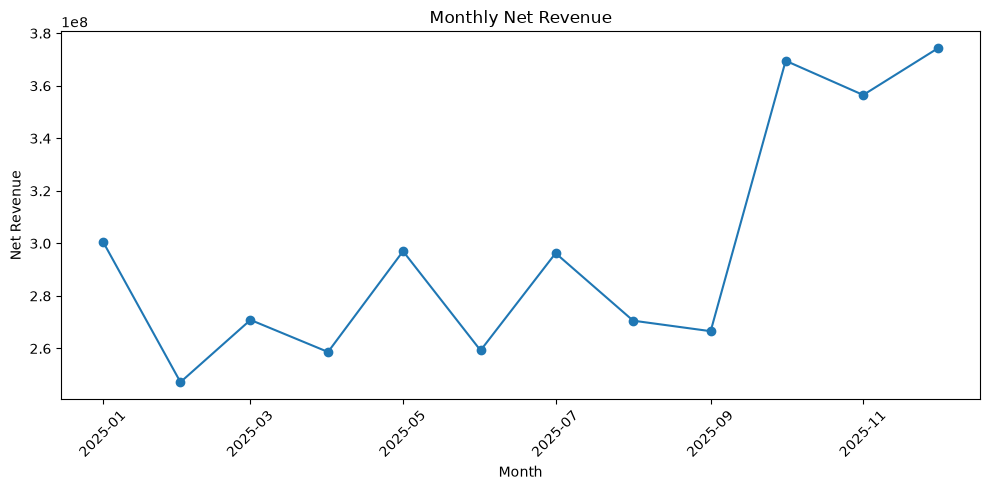

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["revenue"], marker="o")
plt.title("Monthly Net Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly.to_csv(OUT / "monthly_kpis.csv", index=False)

## 7. Customer analysis

In [10]:
customer_summary = (
    order_level.groupby("customer_id", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        net_revenue=("net_revenue", "sum"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
    )
    .merge(customers[["customer_id", "customer_name", "region", "acquisition_channel"]],
           on="customer_id", how="left")
)

customer_summary["customer_type"] = np.where(
    customer_summary["delivered_orders"] >= 2, "Repeat", "One-time"
)

print("Top 20 customers")
display(customer_summary.sort_values("net_revenue", ascending=False).head(20))

repeat_rate = 100 * (customer_summary["customer_type"].eq("Repeat").sum() / len(customer_summary))
print(f"Repeat customer rate: {repeat_rate:.2f}%")

Top 20 customers


,customer_id,delivered_orders,net_revenue,first_order_date,last_order_date,customer_name,region,acquisition_channel,customer_type
10615,12821,67,"3,898,614.54",2025-01-02,2025-12-30,Isaac Mani,North,Social,Repeat
104,127,63,"3,417,707.29",2025-01-03,2025-12-26,Lekha Gupta,North,Email,Repeat
16456,19839,47,"3,195,586.54",2025-01-09,2025-12-28,Darpan Choudhry,South,Email,Repeat
7080,8553,71,"3,171,233.34",2025-01-03,2025-12-26,Radha Munshi,South,Organic,Repeat
10445,12613,55,"3,156,028.39",2025-01-15,2025-12-20,Nandini Hegde,West,Social,Repeat
1347,1621,58,"3,112,982.00",2025-01-09,2025-12-29,Bhanumati Iyer,North,Social,Repeat
2769,3356,53,"2,934,730.90",2025-01-02,2025-12-19,Wishi Din,North,Paid Search,Repeat
8766,10570,52,"2,930,811.52",2025-01-08,2025-12-31,Nirja Mahal,South,Social,Repeat
11043,13321,68,"2,902,655.92",2025-01-01,2025-12-30,Pavani Ratta,East,Organic,Repeat
10277,12415,48,"2,692,224.53",2025-01-06,2025-12-28,Veda Bhavsar,South,Social,Repeat


Repeat customer rate: 76.28%


In [11]:
customer_pareto = customer_summary[["customer_id", "net_revenue"]].sort_values(
    "net_revenue", ascending=False
).copy()
customer_pareto["cumulative_share"] = (
    customer_pareto["net_revenue"].cumsum() / customer_pareto["net_revenue"].sum()
)
customers_to_80pct = int((customer_pareto["cumulative_share"] < 0.80).sum()) + 1
print(f"Customers needed to reach ~80% of revenue: {customers_to_80pct:,}")
customer_pareto.to_csv(OUT / "customer_pareto.csv", index=False)

Customers needed to reach ~80% of revenue: 6,845


## 8. Product and category analysis

In [12]:
category = (
    line.groupby("category", as_index=False)
    .agg(
        units_sold=("quantity", "sum"),
        net_sales=("net_sales", "sum"),
        refunds=("refunds", "sum"),
        cogs=("cogs", "sum"),
    )
)
category["net_revenue"] = category["net_sales"] - category["refunds"]
category["gross_profit"] = category["net_sales"] - category["cogs"]
category["gross_margin_pct"] = 100 * category["gross_profit"] / category["net_sales"]
category = category.sort_values("net_revenue", ascending=False)
category

,category,units_sold,net_sales,refunds,cogs,net_revenue,gross_profit,gross_margin_pct
1,Electronics,46532,"2,255,420,131.08","87,743,900.83","1,258,342,851.39","2,167,676,230.25","997,077,279.69",44.21
3,Home,39336,"627,739,765.93","23,601,314.20","329,048,415.00","604,138,451.73","298,691,350.93",47.58
4,Sports,41436,"443,279,031.68","16,246,832.06","236,548,774.71","427,032,199.62","206,730,256.97",46.64
2,Fashion,32657,"220,149,079.17","8,784,425.45","120,018,083.64","211,364,653.72","100,130,995.53",45.48
0,Beauty,38973,"163,606,276.64","6,263,789.82","87,332,163.70","157,342,486.82","76,274,112.94",46.62


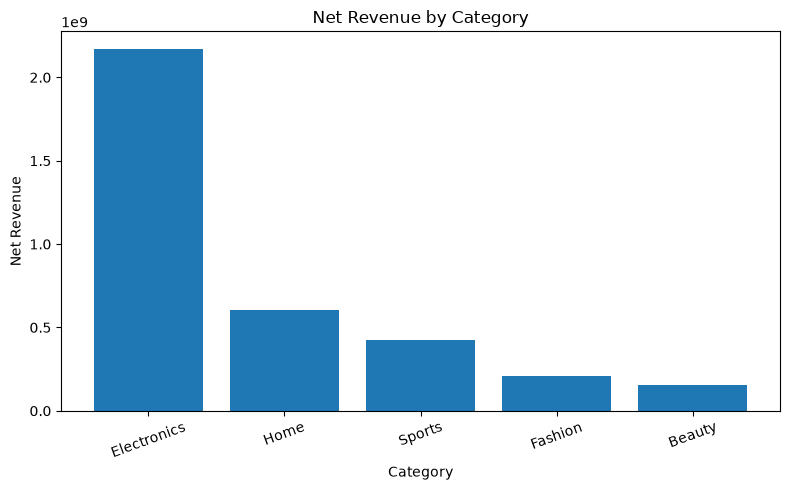

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(category["category"], category["net_revenue"])
plt.title("Net Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [14]:
product = (
    line.groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(units_sold=("quantity", "sum"), net_sales=("net_sales", "sum"), cogs=("cogs", "sum"))
)
product["gross_profit"] = product["net_sales"] - product["cogs"]
product["gross_margin_pct"] = 100 * product["gross_profit"] / product["net_sales"]

print("Top 20 products by net sales")
display(product.sort_values("net_sales", ascending=False).head(20))
product.to_csv(OUT / "product_performance.csv", index=False)

Top 20 products by net sales


,product_id,product_name,category,units_sold,net_sales,cogs,gross_profit,gross_margin_pct
386,387,Pulse Laptops Product 0387,Electronics,3568,"244,329,607.38","144,897,443.36","99,432,164.02",40.70
369,370,UrbanX Audio Product 0370,Electronics,2318,"154,927,752.32","93,131,074.12","61,796,678.20",39.89
312,313,Nova Phones Product 0313,Electronics,2181,"107,272,439.00","62,284,169.22","44,988,269.78",41.94
176,177,Mira Audio Product 0177,Electronics,1239,"96,493,103.13","39,040,059.87","57,453,043.26",59.54
483,484,Vertex Phones Product 0484,Electronics,964,"75,111,342.75","46,635,052.04","28,476,290.71",37.91
179,180,Nova Accessories Product 0180,Electronics,1240,"69,760,957.67","38,779,561.60","30,981,396.07",44.41
294,295,Aster Audio Product 0295,Electronics,966,"68,618,845.66","45,924,190.62","22,694,655.04",33.07
260,261,Nova Phones Product 0261,Electronics,1256,"65,494,245.32","31,615,680.32","33,878,565.00",51.73
255,256,Aster Phones Product 0256,Electronics,1214,"64,176,106.01","44,093,645.44","20,082,460.57",31.29
249,250,Vertex Accessories Product 0250,Electronics,563,"52,848,301.05","27,734,629.86","25,113,671.19",47.52


## 9. Returns analysis

In [15]:
return_summary = (
    returns.groupby("reason", as_index=False)
    .agg(return_events=("return_id", "count"), units_returned=("return_qty", "sum"), refund_amount=("refund_amount", "sum"))
    .sort_values("refund_amount", ascending=False)
)
return_summary

,reason,return_events,units_returned,refund_amount
0,Changed Mind,1348,1562,"30,361,968.20"
1,Damaged,1318,1555,"29,080,159.25"
4,Wrong Item,1266,1513,"28,594,136.52"
2,Not as Expected,1242,1479,"27,314,115.84"
3,Size Issue,1305,1580,"27,289,882.55"


In [16]:
sold_units = line.groupby("product_id", as_index=False)["quantity"].sum().rename(columns={"quantity": "units_sold"})
returned_units = (
    returns.merge(order_items[["order_item_id", "product_id"]], on="order_item_id", how="left")
    .groupby("product_id", as_index=False)["return_qty"].sum()
    .rename(columns={"return_qty": "units_returned"})
)
product_returns = (
    sold_units.merge(returned_units, on="product_id", how="left")
    .fillna({"units_returned": 0})
    .merge(products[["product_id", "product_name", "category"]], on="product_id", how="left")
)
product_returns["return_rate_pct"] = 100 * product_returns["units_returned"] / product_returns["units_sold"]
product_returns.sort_values("return_rate_pct", ascending=False).head(20)

,product_id,units_sold,units_returned,product_name,category,return_rate_pct
421,422,157,16.00,Nexa Men Product 0422,Fashion,10.19
61,62,75,7.00,Orion Accessories Product 0062,Electronics,9.33
160,161,227,21.00,Pulse Fitness Product 0161,Sports,9.25
370,371,160,14.00,Pulse Bags Product 0371,Fashion,8.75
477,478,174,15.00,Orion Furniture Product 0478,Home,8.62
147,148,117,10.00,Orion Footwear Product 0148,Fashion,8.55
450,451,24,2.00,Nova Bags Product 0451,Fashion,8.33
47,48,98,8.00,Prime Haircare Product 0048,Beauty,8.16
493,494,135,11.00,Nova Sportswear Product 0494,Sports,8.15
30,31,87,7.00,Mira Outdoor Product 0031,Sports,8.05


## 10. Profitability by region

In [17]:
# Use order-level data here so shipping_cost is counted once per order.
region_profit = (
    order_level.merge(customers[["customer_id", "region"]], on="customer_id", how="left")
    .groupby("region", as_index=False)
    .agg(
        net_revenue=("net_revenue", "sum"),
        cogs=("cogs", "sum"),
        shipping_cost=("shipping_cost", "sum"),
    )
)
region_profit["contribution_profit"] = (
    region_profit["net_revenue"] - region_profit["cogs"] - region_profit["shipping_cost"]
)
region_profit["margin_pct"] = 100 * region_profit["contribution_profit"] / region_profit["net_revenue"]
region_profit.sort_values("contribution_profit", ascending=False)

,region,net_revenue,cogs,shipping_cost,contribution_profit,margin_pct
1,North,"1,112,839,838.34","634,435,497.35","2,845,067.52","475,559,273.47",42.73
2,South,"909,155,857.45","517,427,239.42","2,357,337.56","389,371,280.47",42.83
0,East,"867,260,478.08","493,814,441.48","2,231,811.96","371,214,224.64",42.80
3,West,"678,297,848.26","385,613,110.19","1,718,677.34","290,966,060.73",42.90


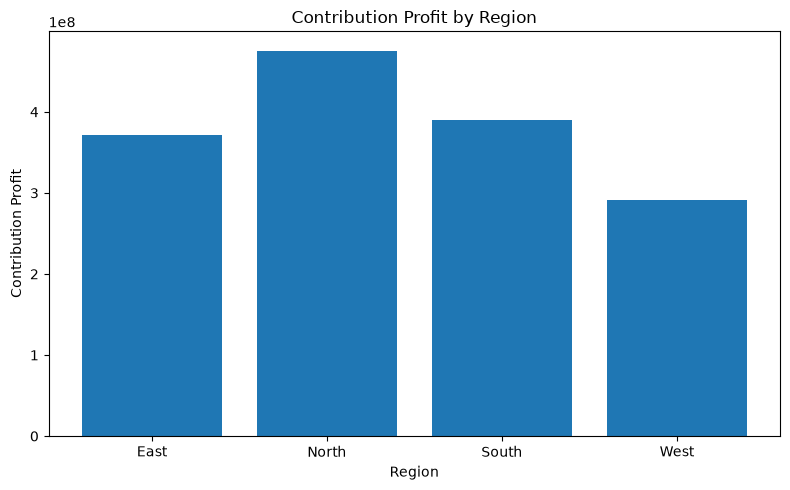

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(region_profit["region"], region_profit["contribution_profit"])
plt.title("Contribution Profit by Region")
plt.xlabel("Region")
plt.ylabel("Contribution Profit")
plt.tight_layout()
plt.show()

## 11. SQL vs Python validation

The PostgreSQL project should be treated as the primary SQL implementation. Compare the shared KPIs against the Python calculations. The expected shared metrics are delivered orders, purchasing customers, net revenue and AOV.

In [19]:
# Python-side values for comparison with the SQL validation query (sql/13_validation.sql).
python_validation = pd.Series({
    "delivered_orders": int(order_level["order_id"].nunique()),
    "purchasing_customers": int(order_level["customer_id"].nunique()),
    "net_revenue": round(float(order_level["net_revenue"].sum()), 2),
    "aov": round(float(order_level["net_revenue"].mean()), 2),
}, name="python")
python_validation

delivered_orders              70,437.00
purchasing_customers          16,595.00
net_revenue            3,567,554,022.14
aov                           50,648.86
Name: python, dtype: float64

Run `./run_sql.sh sql/13_validation.sql` in the terminal and compare its four values with the cell above. They should match after rounding. If they do not, investigate grain, joins, filters or refund aggregation before continuing.

## 12. Key findings and recommendations

In [20]:
# Fill these using the actual outputs above. Do not invent conclusions.
strongest_month = monthly.loc[monthly["revenue"].idxmax(), "month"]
weakest_month = monthly.loc[monthly["revenue"].idxmin(), "month"]
strongest_category = category.iloc[0]["category"]
highest_profit_region = region_profit.sort_values("contribution_profit", ascending=False).iloc[0]["region"]

print(f"Strongest revenue month: {strongest_month:%Y-%m}")
print(f"Weakest revenue month: {weakest_month:%Y-%m}")
print(f"Top category by net revenue: {strongest_category}")
print(f"Top region by contribution profit: {highest_profit_region}")
print(f"Repeat customer rate: {repeat_rate:.2f}%")

Strongest revenue month: 2025-12
Weakest revenue month: 2025-02
Top category by net revenue: Electronics
Top region by contribution profit: North
Repeat customer rate: 76.28%


### Recommendation framework
- If repeat-customer share is low, prioritize retention and second-purchase programs.
- If a category has high revenue but weak margin, review discounting, product mix and costs.
- If a product has an unusually high return rate, investigate the operational reason before increasing promotion.
- If regional profitability differs materially, allocate growth effort using contribution margin rather than revenue alone.
- Treat campaign performance as descriptive unless the data supports causal attribution.

## 13. Export analysis tables
The notebook writes reusable CSV outputs to `notebooks/outputs/` for review or dashboarding.

In [21]:
category.to_csv(OUT / "category_performance.csv", index=False)
return_summary.to_csv(OUT / "return_summary.csv", index=False)
region_profit.to_csv(OUT / "region_profitability.csv", index=False)
print("Outputs written to:", OUT)

Outputs written to: /home/rishabh/Projects/ecommerce_sql_project/notebooks/outputs
